### VGG with additional features

In [ ]:
end_time = time.time()
print(f"Total Training Time: {(end_time - start_time)/60:.2f} minutes")


Total Training Time: 10.85 minutes


32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 201ms/step


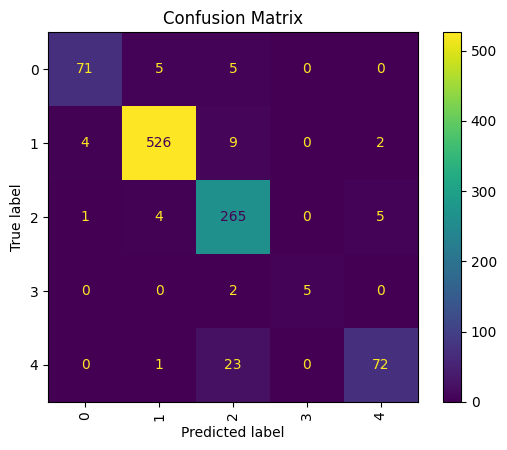

AUC Score: 0.9932


In [ ]:
y_true = np.argmax(val_labels_cat, axis=1)
y_pred_prob = model.predict(val_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()

# AUC Score (macro)
auc_score = roc_auc_score(val_labels_cat, y_pred_prob, multi_class='ovo')
print(f"AUC Score: {auc_score:.4f}")

<ipython-input-21-74bb69ac7861>:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cycle(plt.cm.get_cmap('tab10').colors)


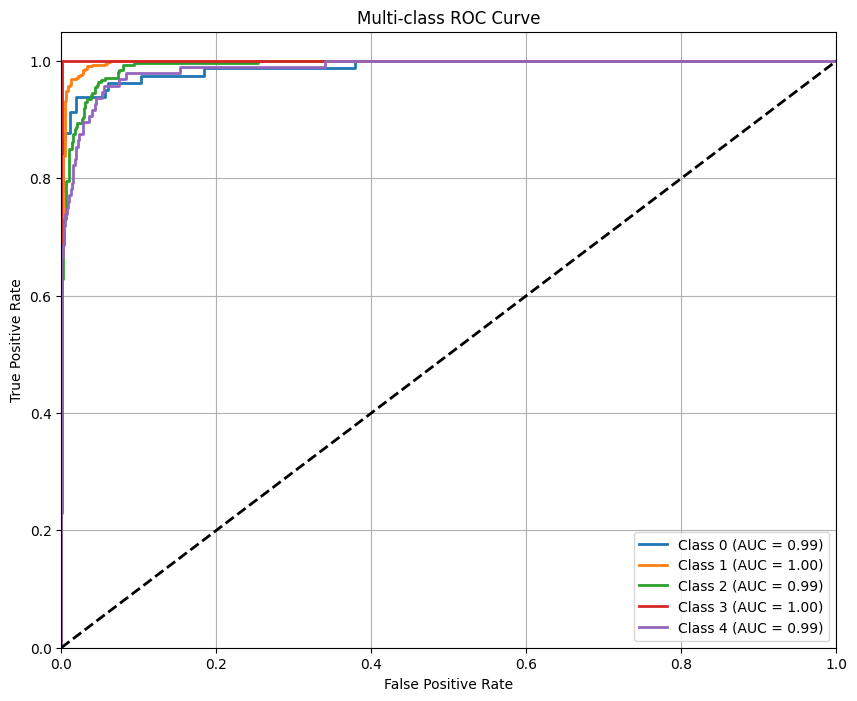

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from itertools import cycle

# ROC Curve per class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = num_classes

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(val_labels_cat[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(plt.cm.get_cmap('tab10').colors)

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### VGG with Additional Features (Alternate)

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.70      0.78      3134
           1       0.95      0.97      0.96     21609
           2       0.87      0.91      0.89     11206
           3       0.88      0.68      0.77       336
           4       0.86      0.75      0.80      3714

    accuracy                           0.91     39999
   macro avg       0.89      0.80      0.84     39999
weighted avg       0.91      0.91      0.91     39999



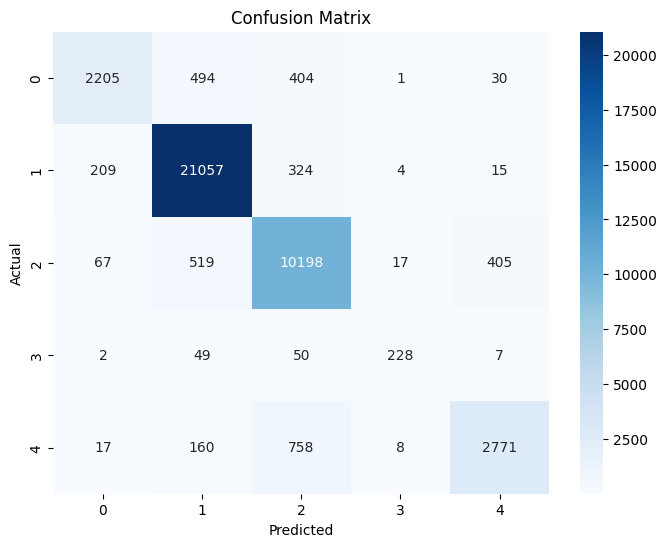

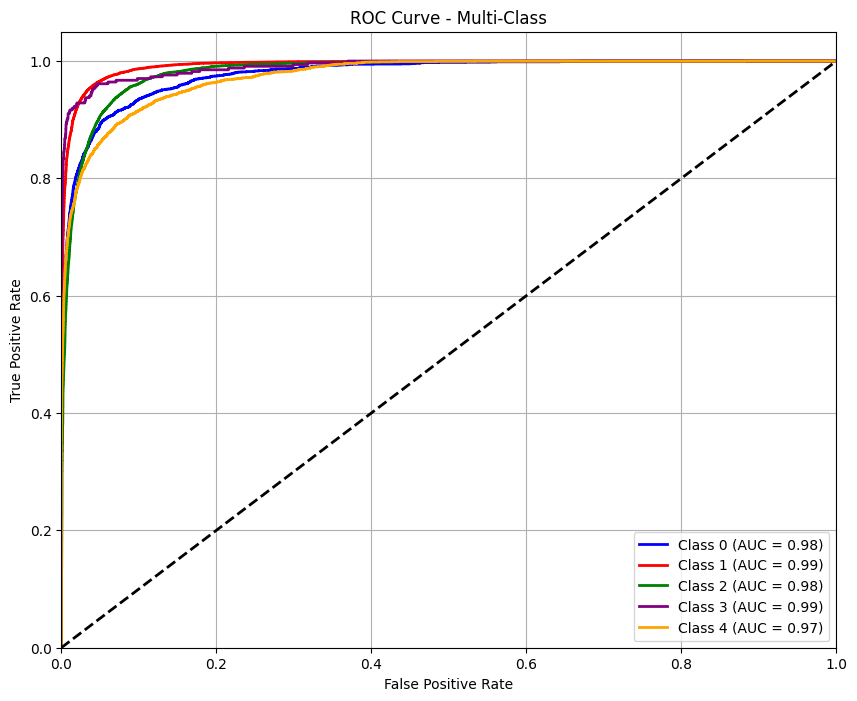

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve & AUC
n_classes = 5
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'purple', 'orange']
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Multi-Class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### EfficientNet Transfer Learning

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import numpy as np
import torch.nn.functional as F

def evaluate_model(model, dataloader, num_classes=5):
    model.eval()
    total, correct = 0, 0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        loop = tqdm(dataloader, desc="Evaluating", leave=False)
        for imgs, labels in loop:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

            loop.set_postfix(accuracy=100*correct/total)

    acc = 100 * correct / total
    print(f"Evaluation Accuracy: {acc:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()

    # ROC AUC per class
    all_labels_onehot = np.eye(num_classes)[all_labels]  # One-hot encode labels
    all_probs = np.array(all_probs)

    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(all_labels_onehot[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

    plt.plot([0,1], [0,1], 'k--')  # Diagonal
    plt.title("ROC Curve per Class")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()


Evaluation of EfficientNet-Unfreeze


Evaluation Accuracy: 92.77%


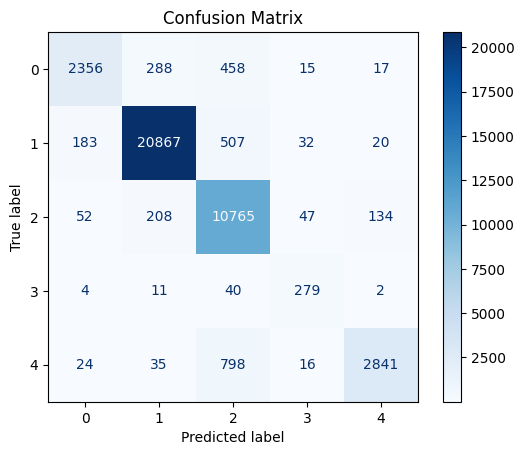

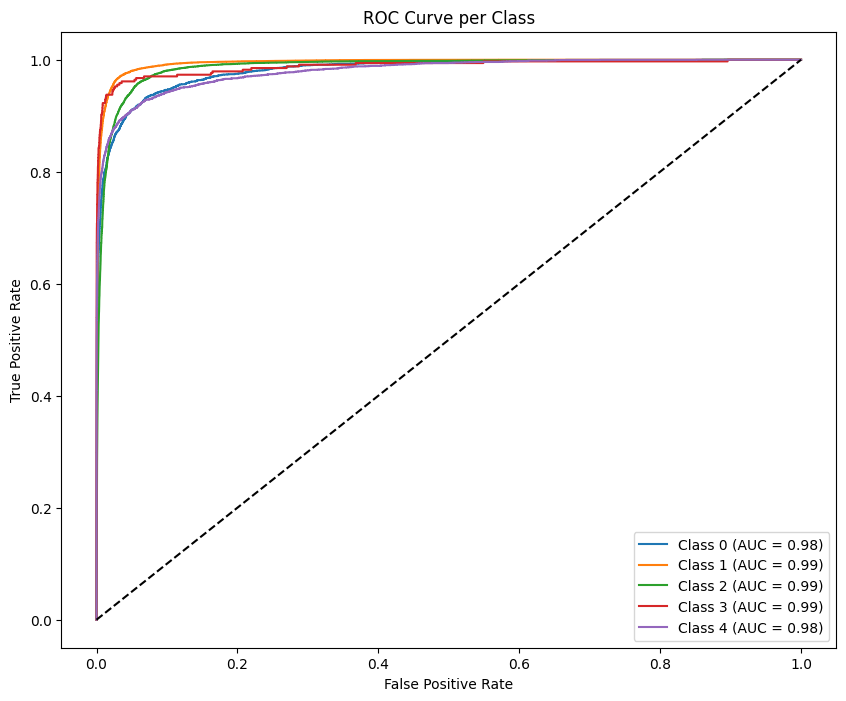

In [ ]:
print(f"\nEvaluation of EfficientNet-Unfreeze")
evaluate_model(model1, test_loader, num_classes=5)


Evaluation of EfficientNet-AddedLayers


Evaluation Accuracy: 92.61%


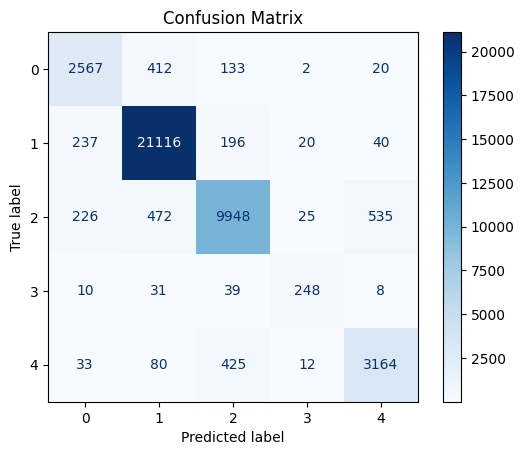

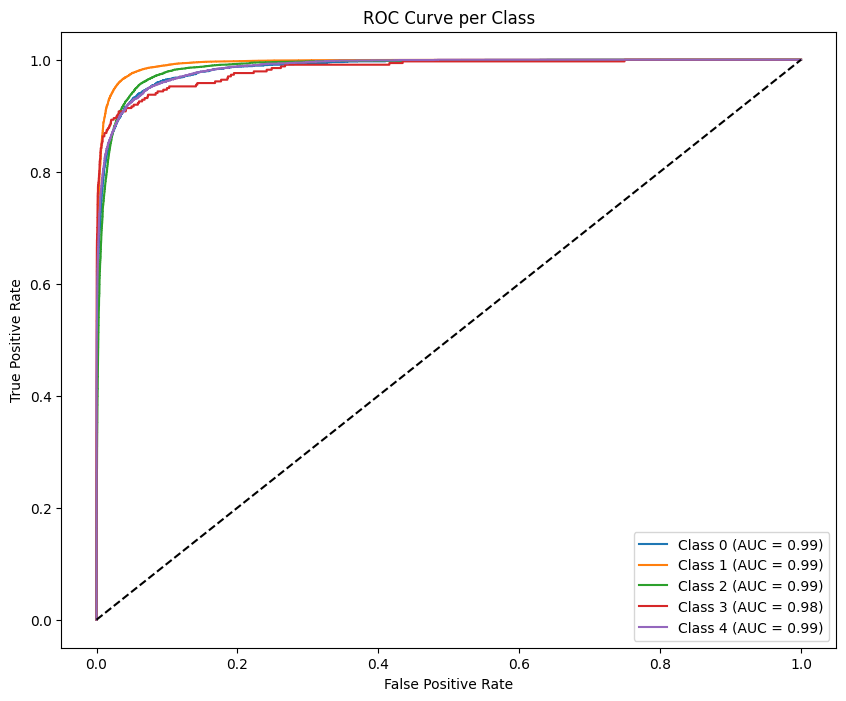

In [ ]:
print(f"\nEvaluation of EfficientNet-AddedLayers")
evaluate_model(model2, test_loader, num_classes=5)

### VGG with Partial Layer Unfreezing

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 191ms/step
Classification Report:
              precision    recall  f1-score   support

       drink       0.21      0.22      0.22       200
        food       0.18      0.17      0.18       200
      inside       0.17      0.14      0.16       200
        menu       0.17      0.17      0.17       200
     outside       0.20      0.22      0.21       200

    accuracy                           0.19      1000
   macro avg       0.19      0.19      0.19      1000
weighted avg       0.19      0.19      0.19      1000



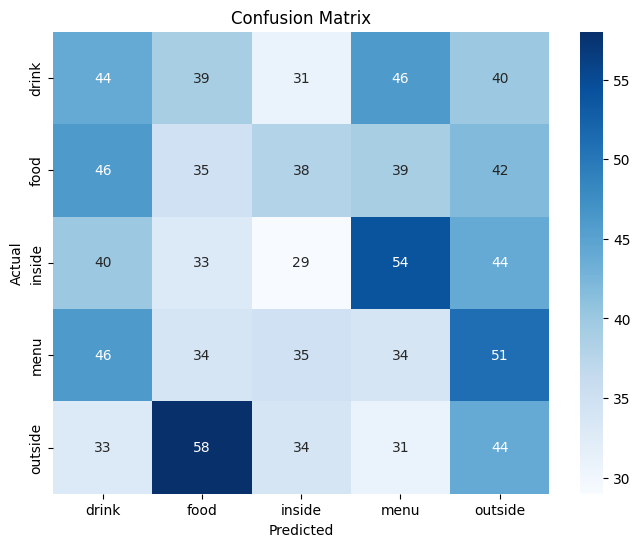

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict on validation data
val_gen.reset()
y_pred = model.predict(val_gen, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


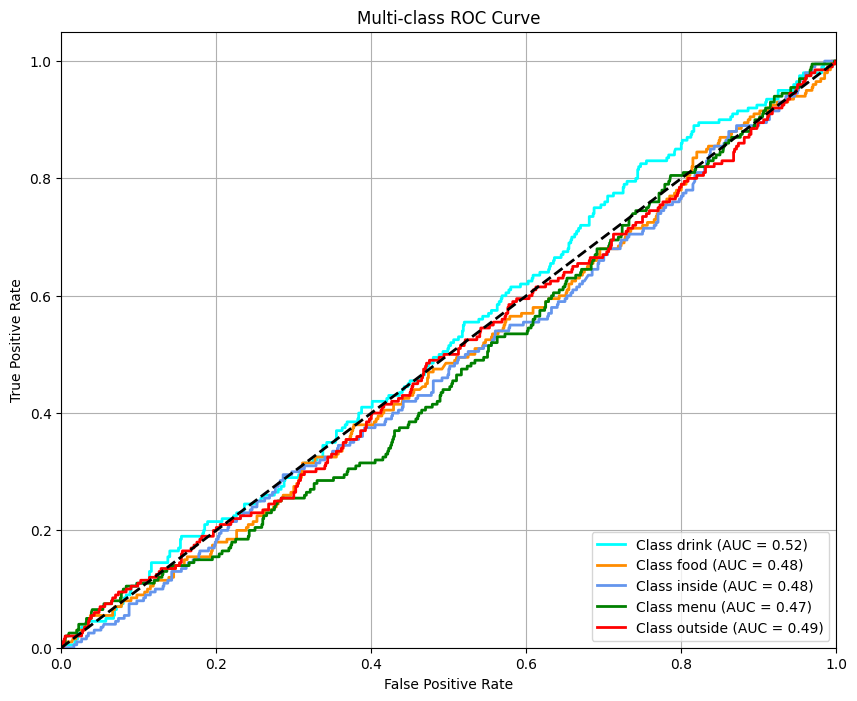

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the labels for ROC computation
y_true_bin = label_binarize(y_true, classes=list(range(len(class_labels))))

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red'])

for i, color in zip(range(len(class_labels)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='Class {} (AUC = {:.2f})'.format(class_labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### VGG Fully Trainable

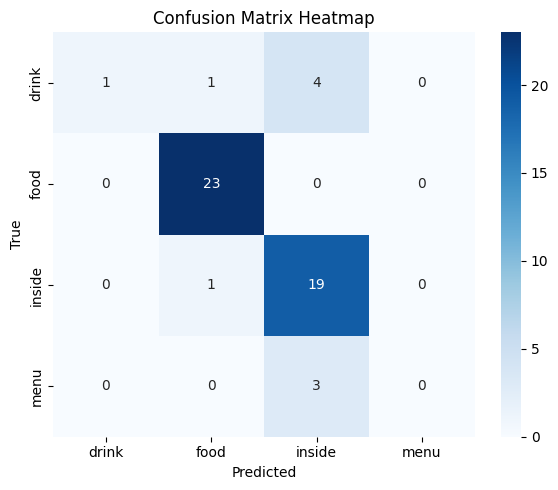

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
present_classes = np.unique(y_true)
present_class_names = label_encoder.inverse_transform(present_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_class_names,
            yticklabels=present_class_names)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()


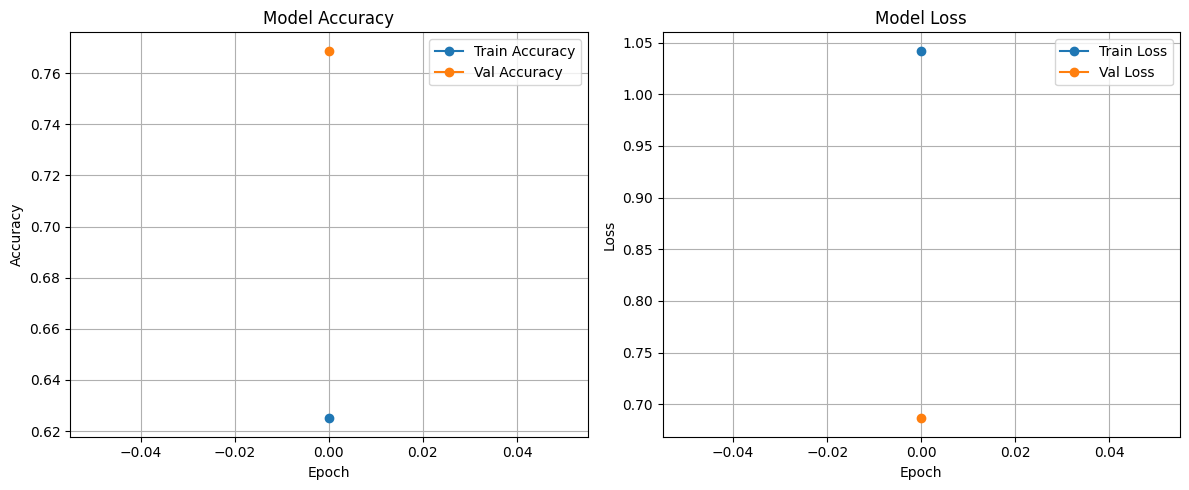

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
